# Solving the Grid World Problem using Value Iteration

In this notebook, we apply our implementation of the value iteration algorithm to solve a stochastic Grid World problem.

The goal is to compute:
- the optimal value function V(s)
- the optimal policy

This demonstrates that our implementation is reusable and works for different Markov Decision Processes (MDPs).

An MDP consists of:

- States (S): positions in the grid
- Actions (A): moves like Left, Right, Up, Down
- Transitions (P): probabilities of moving between states
- Rewards (R): immediate reward after each move
- Discount factor (γ): importance of future rewards

The value iteration algorithm computes the best possible decision in each state.

In [4]:
from value_iteration.algorithm import value_iteration
from value_iteration.policy import extract_policy

In [5]:
# States
states = ["TL", "TR", "BL", "BR"]

# Actions
actions = {
    "TL": ["R", "D"],
    "TR": ["L", "D"],
    "BL": ["R", "U"]
}

# Transitions
transitions = {
    ("TL","R"): [(0.9,"TR"), (0.1,"BL")],
    ("TL","D"): [(0.9,"BL"), (0.1,"TR")],

    ("TR","L"): [(0.9,"TL"), (0.1,"BR")],
    ("TR","D"): [(0.8,"BR"), (0.2,"TL")],

    ("BL","R"): [(0.9,"BR"), (0.1,"TL")],
    ("BL","U"): [(0.8,"TL"), (0.2,"BR")]
}

# Rewards
rewards = {
    ("TL","R","TR"): -1,
    ("TL","R","BL"): -2,
    ("TL","D","BL"): -2,
    ("TL","D","TR"): -1,

    ("TR","L","TL"): -1.5,
    ("TR","L","BR"): 10,
    ("TR","D","BR"): 15,
    ("TR","D","TL"): -1,

    ("BL","R","BR"): 20,
    ("BL","R","TL"): -2.5,
    ("BL","U","TL"): -0.5,
    ("BL","U","BR"): 5
}

In [7]:
V, policy = value_iteration(states, actions, transitions, rewards)

print("Value Function:", V)
print("Policy:", policy)

Value Function: {'TL': 14.863870833504835, 'TR': 14.47549675003087, 'BL': 19.087748375015437, 'BR': 0}
Policy: {'TL': 'D', 'TR': 'D', 'BL': 'R', 'BR': None}


## Interpretation of Results

The value function V(s) gives the expected long-term reward starting from each state.

We observe that:
- The bottom-left state (BL) has the highest value, as it is closest to the highest reward.
- The bottom-right state (BR) is terminal, so its value is 0.
- The optimal policy suggests moving towards states with higher rewards.

This confirms that the value iteration algorithm correctly identifies optimal decisions.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
V_matrix = np.array([
    [V["TL"], V["TR"]],
    [V["BL"], V["BR"]]
])

policy_matrix = np.array([
    [policy["TL"], policy["TR"]],
    [policy["BL"], policy["BR"]]
])

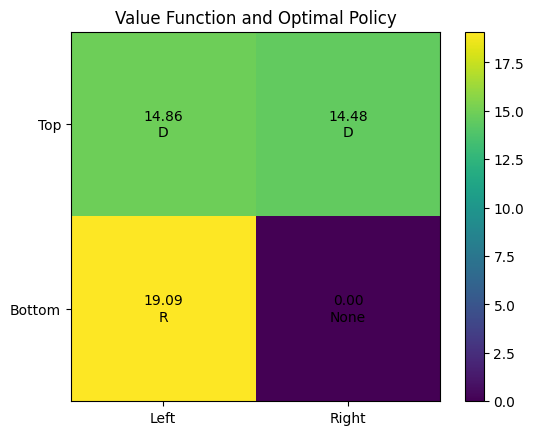

In [14]:
plt.figure()

plt.imshow(V_matrix)

for i in range(2):
    for j in range(2):
        text = f"{V_matrix[i,j]:.2f}\n{policy_matrix[i,j]}"
        plt.text(j, i, text, ha='center', va='center')

plt.title("Value Function and Optimal Policy")
plt.xticks([0,1], ["Left","Right"])
plt.yticks([0,1], ["Top","Bottom"])

plt.colorbar()
plt.show()

##Results

The visualisation above helps us understand how the value iteration algorithm behaves in the Grid World.

States with higher values (shown by warmer colours) are those from which the agent can achieve higher long-term rewards. In particular, the bottom-left state (BL) has the highest value because it is closest to the largest reward in the environment.

The optimal policy indicates the best action to take in each state. We can see that the agent is guided towards high-reward states while avoiding transitions that may lead to penalties. Importantly, the algorithm takes into account the stochastic nature of the environment. Because movements are not always certain, the chosen actions balance both reward and risk.

This means the policy is not simaply choosing the shortest path, but rather the path with the highest expected return.

---

## Conclusion

This notebook demonstrates the successful application of the value iteration algorithm to a stochastic Grid World problem.

The implementation correctly computes both the value function and the optimal policy, and it can be applied to different Markov Decision Processes, as shown earlier with the Sam example.

The results confirm that the algorithm converges and produces sensible decisions based on expected future rewards. The structure of the project also supports reproducibility, as the implementation is modular, tested, and can be reused for other problems.

Overall, this confirms both the correctness of the algorithm and its practical usefulness for solving decision-making problems under uncertainty.